# Multi-core exploration — template

Copy this notebook, change the **Configuration** cell, run all.

- `multi_core_runs.py`: `generate_problem`, `run_single`, `run_grid`, `run_study`, `build_hierarchy`, `trace_sweeps`
- `multi_core_utils.py`: configs, saved runs (`save_run`, `load_run`), plots

A **point** is `(nb_partitions, nb_node_per_meta_nodes)`. The point `(1, 0)` is the single-core baseline: it is solved with the plain Multiplicative solver instead of the hierarchical one.

The problem is generated once and every point solves a copy of it, so all the points of a run see exactly the same model.

In [1]:
%load_ext autoreload
%autoreload 2 --full
%matplotlib inline

import multi_core_runs as runs   # sets TOP, one BLAS thread per process, no per-trial progress bars
import multi_core_utils as utils

## Configuration

`config` is the base yaml with the changes below. Any other key of the yaml can be passed to `make_config` the same way; a key that is not in the yaml raises an error.

`BENCHMARK` selects the problem: a file of `ising/benchmarks/` (or a list of files), or `None` for a problem generated from `SIZE` and `CONNECTIVITY`. With a benchmark, `SIZE` and `CONNECTIVITY` are not used.

`BENCHMARK`, `NB_CONNECTION_PER_SPIN` and `NB_SWEEPS` take one value or a list of values. The sections on one problem (problem, single run, hierarchy, sweeps) use the first value; the study runs all of them.

In [2]:
PROBLEM_TYPE = "Maxcut"

# A file of ising/benchmarks/, or a list of them; utils.find_benchmarks("G/regenerated/G3[2-4]_*.txt") lists the files of a pattern.
# None: dummy mode, a problem generated by the dummy creator from SIZE and CONNECTIVITY.
BENCHMARK = [
    "G/regenerated/G32_2000_4000_toroidal_1410.txt",
    "G/regenerated/G29_2000_19990_random_3405.txt",
    "G/regenerated/G40_2000_11766_planar_2400.txt",
    "G/regenerated/K2000_2000_1999000_dense_33337.txt"
            ]

# A yaml of config_files/, or a path. maxcut_benchmark has the dummy creator off, maxcut_c1 has it on.
BASE_CONFIG = "maxcut_benchmark" if BENCHMARK else "maxcut_c1"

#SIZE = 1024                       # number of spins (dummy mode only)

#NB_CONNECTION_PER_SPIN = [1023,      # spins a spin is coupled to: one value or a list, e.g. [1023, 512, 205]
# Fraction of the other spins a spin is coupled to, for each number of connections per spin (dummy mode only)
#CONNECTIVITY = [1.0, 0.9, 0.5,0.1,0.05] #[connections / (SIZE - 1) for connections in utils.as_list(NB_CONNECTION_PER_SPIN)]

NB_RUNS = 20                      # trials per point (about 2 to 7 s per trial at 1024 spins)

NB_PARTITIONS = [2, 3, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]   # number of partitions of the problem: one value or a list
NB_NODE_PER_META_NODES = [2, 3, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
NB_SWEEPS = 2             # upper-then-partitions cycles of the hierarchical solver: one value or a list

NB_WORKERS = 7                 # points solved at the same time; None: all CPUs, 1: in this process
NICE = 0                          # positive on a shared server
RESULTS_DIR = utils.RESULTS_DIR   # where the runs are saved



config = utils.make_config(
    utils.load_config(BASE_CONFIG),
    PROBLEM_TYPE,
    nb_runs=NB_RUNS,
    nb_sweeps_Hierarchical_solver=utils.as_list(NB_SWEEPS)[0],
)
if BENCHMARK:
    # The first benchmark for the sections on one problem; the study runs all of them
    config = utils.set_benchmark(config, utils.as_list(BENCHMARK)[0])
    problems = f"benchmark {utils.as_list(BENCHMARK)}"
else:
    config = utils.make_config(config, PROBLEM_TYPE, dummy_size=SIZE, dummy_connectivity=CONNECTIVITY[0])
    problems = f"connectivity {[round(value, 3) for value in CONNECTIVITY]}"
grid = utils.make_grid(NB_PARTITIONS, NB_NODE_PER_META_NODES, baseline=True)
print(f"{len(grid)} points, {len(utils.as_list(NB_SWEEPS))} numbers of sweeps, {problems}")

145 points, 1 numbers of sweeps, benchmark ['G/regenerated/G32_2000_4000_toroidal_1410.txt', 'G/regenerated/G29_2000_19990_random_3405.txt', 'G/regenerated/G40_2000_11766_planar_2400.txt', 'G/regenerated/K2000_2000_1999000_dense_33337.txt']


## Problem

Generated once. The connections per spin are counted on the generated `J`.

In [3]:
problems = []
models = []
for benchmark in utils.as_list(BENCHMARK):
    config = utils.set_benchmark(config, benchmark)
    problem = runs.generate_problem(config)
    model = problem["ising_model"]
    problems.append(problem)
    models.append(model)
    print(f"{PROBLEM_TYPE}: {model.num_variables} spins, {utils.connections_per_spin(model):.1f} connections per spin")

problem = problems[0]
model = models[0]

2026-10-08 19:53:28,759 - maxcut_parser_stage.py - get_optim_value +104 - WARNING - Optimal energy file /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/benchmarks/G/regenerated/optimal_energy.txt does not exist. Returning None.


Maxcut: 2000 spins, 4.0 connections per spin
2026-10-08 19:53:28,798 - maxcut_parser_stage.py - get_optim_value +104 - WARNING - Optimal energy file /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/benchmarks/G/regenerated/optimal_energy.txt does not exist. Returning None.
Maxcut: 2000 spins, 20.0 connections per spin
2026-10-08 19:53:28,830 - maxcut_parser_stage.py - get_optim_value +104 - WARNING - Optimal energy file /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/benchmarks/G/regenerated/optimal_energy.txt does not exist. Returning None.
Maxcut: 2000 spins, 11.8 connections per spin


/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/stages/maxcut_parser_stage.py:50: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  coupling = -nx.adjacency_matrix(graph, weight="weight").toarray() / 2


2026-10-08 19:53:29,996 - maxcut_parser_stage.py - get_optim_value +104 - WARNING - Optimal energy file /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/benchmarks/G/regenerated/optimal_energy.txt does not exist. Returning None.
Maxcut: 2000 spins, 1999.0 connections per spin


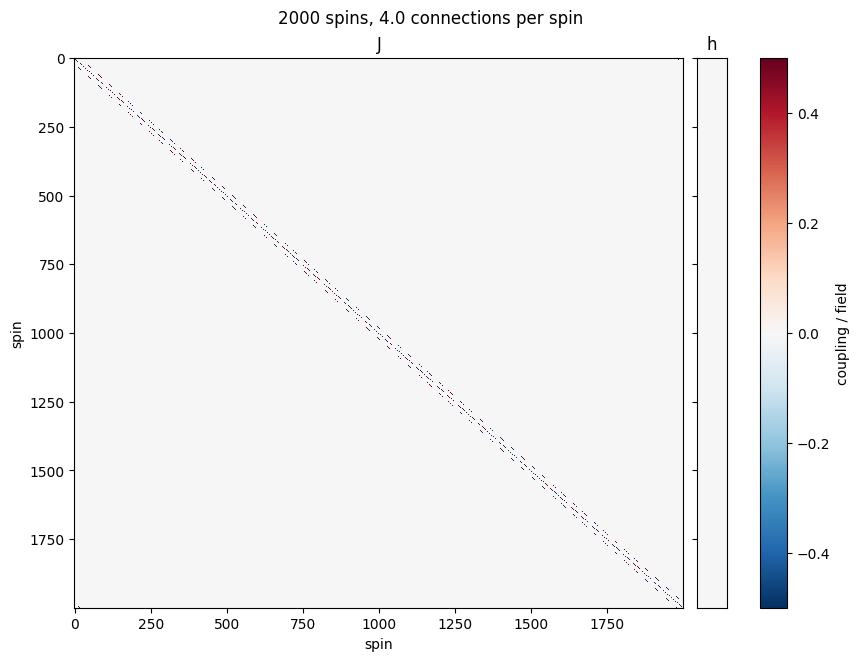

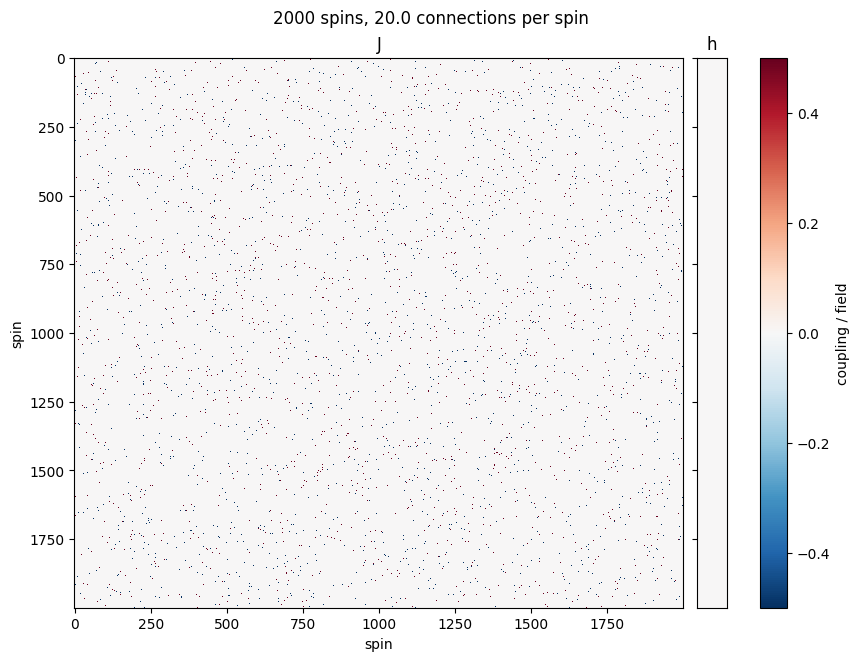

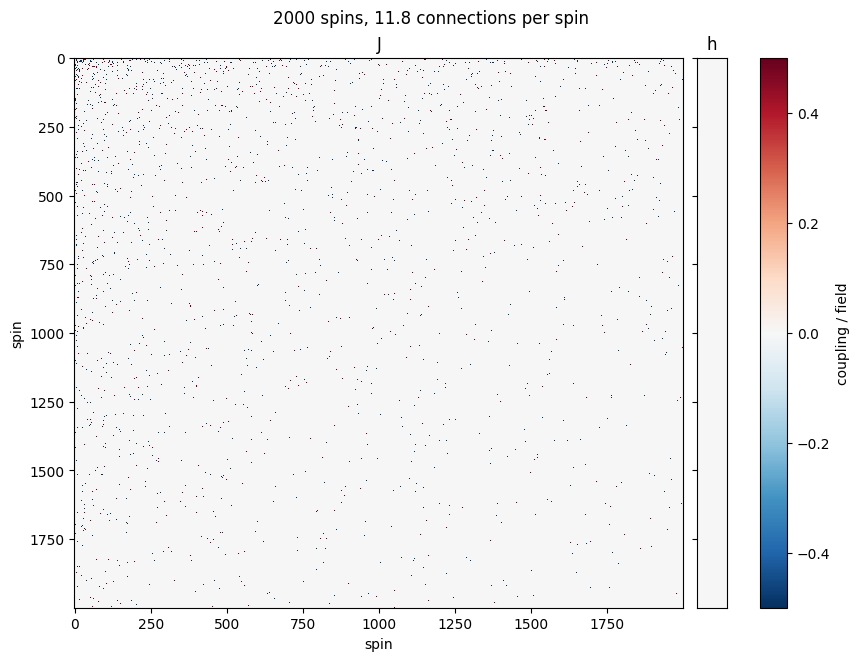

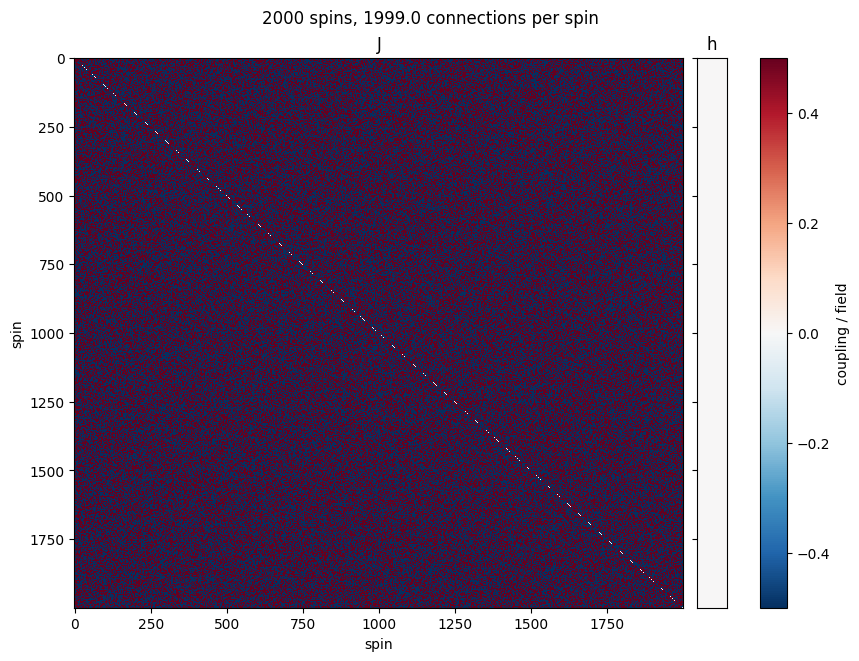

In [4]:
for model in models:
    utils.plot_model(model)

## Single run

One point, in this process. The row gives the point, what it means in spins, and the MIN / 25 % / 50 % / 75 % / MAX of the trial energies.

`nb_node_per_meta_nodes` is the number of nodes (spins) grouped in one meta node. The pipeline config calls it `nb_meta_nodes`; it builds `num_spins // nb_node_per_meta_nodes` meta nodes in total (`total_meta_nodes`), shared between the partitions.

In [10]:
row = runs.run_single(problem, nb_partitions=4, nb_node_per_meta_nodes=4)
row

/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/solvers/Multiplicative.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  self.tau_system = capacitance / (current * np.mean(np.sum(coupling, axis=1)))


{'problem_type': 'Maxcut',
 'benchmark': 'G/regenerated/G32_2000_4000_toroidal_1410.txt',
 'num_spins': 2000,
 'connectivity': 0.002001000500250125,
 'connections_per_spin': 4.0,
 'best_energy': -1410.0,
 'nb_partitions': 4,
 'nb_node_per_meta_nodes': 4,
 'solver': 'Hierarchical_solver',
 'spins_per_partition': 500.0,
 'total_meta_nodes': 500,
 'meta_nodes_per_partition': 125.0,
 'spins_per_meta_node': 4.0,
 'nb_sweeps': 2,
 'nb_trials': 20,
 'en_min': -1304.0,
 'en_25': -1294.0,
 'en_50': -1280.0,
 'en_75': -1274.0,
 'en_max': -1264.0,
 'en_mean': -1283.3,
 'time_mean': 11273.656644535065}

The hierarchy of that point, as the solver builds it before the first sweep: the `J` and `h` of the meta nodes (upper model), then of each partition, with their smallest and largest value underneath. The `h` of a partition is the one of the problem here; the influence of the other partitions is added during the sweeps.

With `partitioning_technique: random` the partitions are drawn again at each trial, so this is then one example.

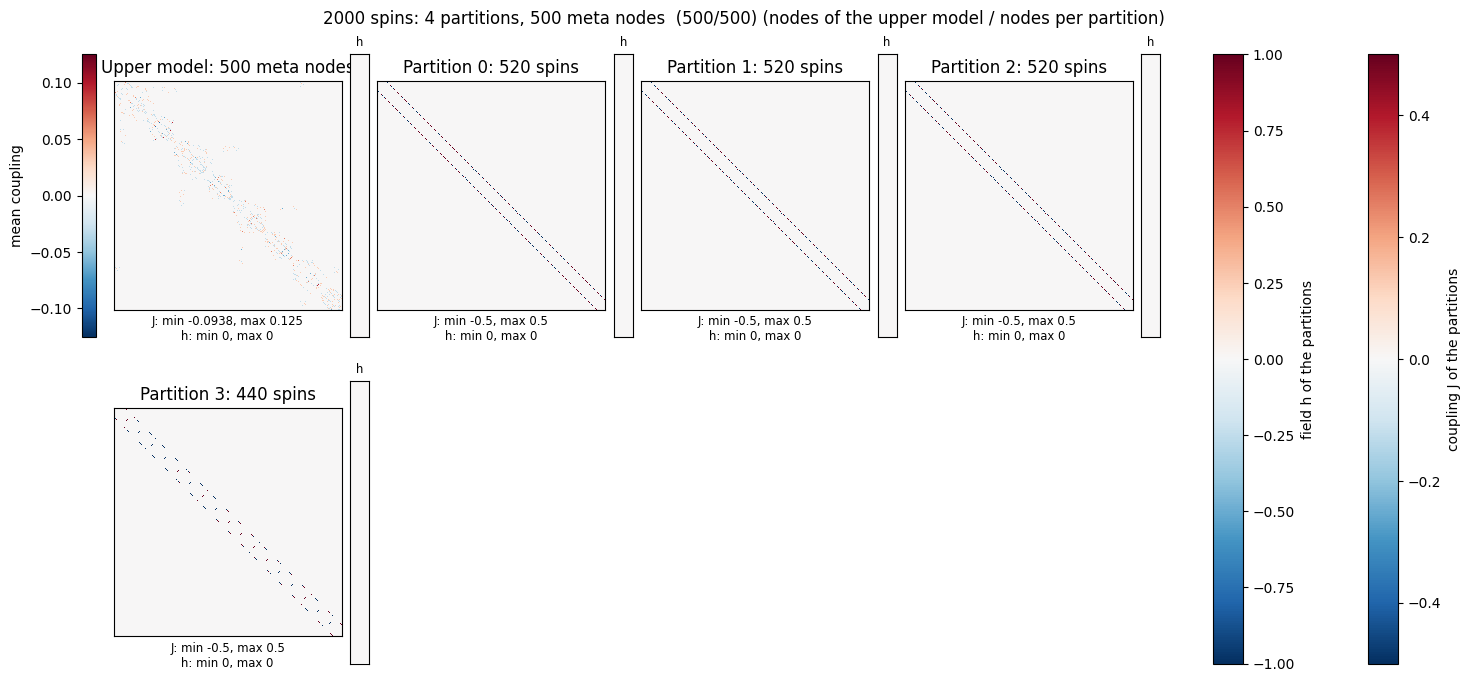

In [35]:
hierarchy = runs.build_hierarchy(problem, nb_partitions=4, nb_node_per_meta_nodes=4)
fig = utils.plot_hierarchy(hierarchy)

The `J` and `h` at sweeps 0, 1, 2, 3 of the first trial, recorded while the solver runs. One row per sweep: the upper model on its own scales, the upper model on the scales of the partitions, then each partition with the `h` it is given at that sweep. The smallest and largest `J` and `h` are under each model; the title gives the largest change since sweep 0.

`plot_sweep_diff` shows the difference between two sweeps (`second` minus `first`): `J`, `h`, and the spins `s` that flipped.

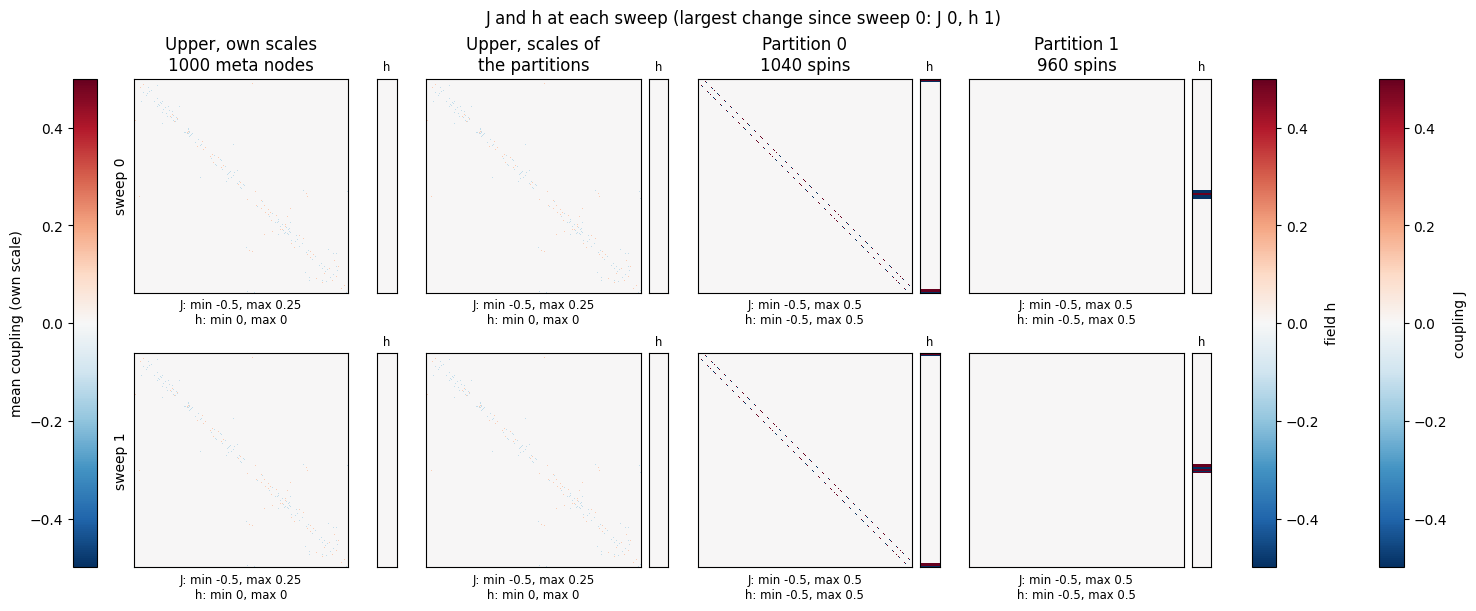

In [36]:
trace = runs.trace_sweeps(problem, nb_partitions=2, nb_node_per_meta_nodes=2, nb_sweeps=2)
fig = utils.plot_sweep_couplings(trace)

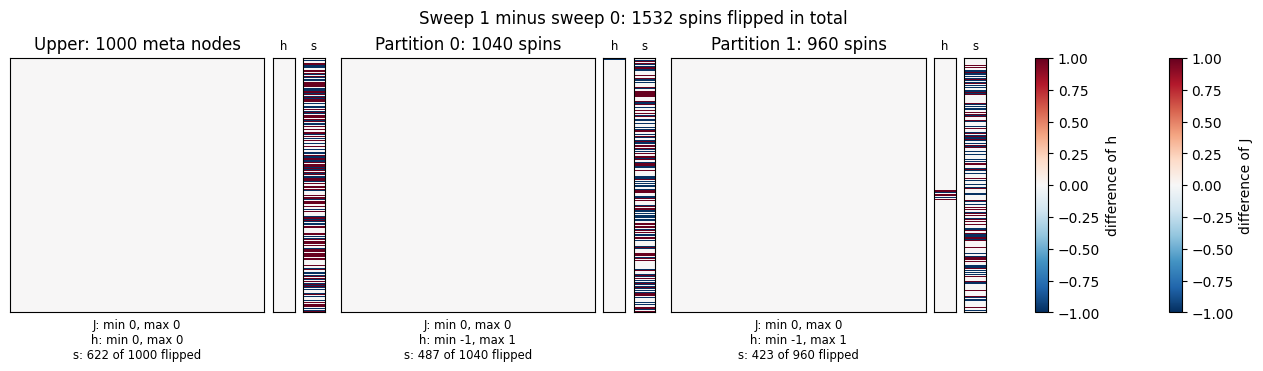

In [37]:
fig = utils.plot_sweep_diff(trace, first=0, second=1)

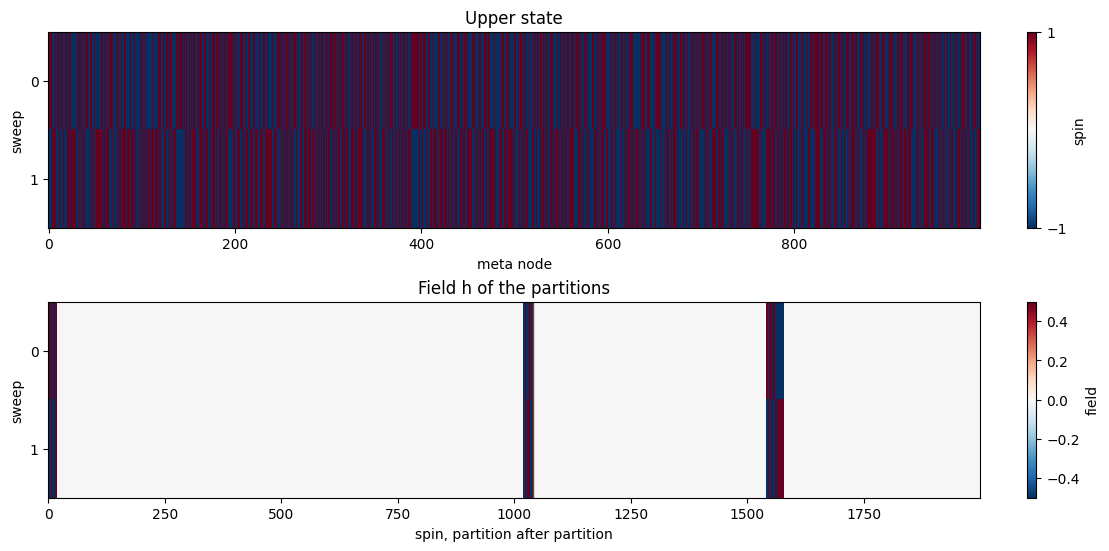

In [38]:
fig = utils.plot_sweep_fields(trace)

## Study

All the points, for every number of sweeps and every connectivity, in parallel. One problem is generated per connectivity (same seed), with its own single-core baseline; for the numbers of sweeps, each point is solved once with the largest one and the energy after each listed number of sweeps is kept.

`save_run` writes a yaml (the config, with the grid and the lists) and a csv (the table) under a verbose name with a timestamp, and links `last_run.yaml` / `last_run.csv` to them.

In [9]:
# The problems of the study: the benchmarks, or in dummy mode one generated problem per connectivity
problems = dict(benchmark=BENCHMARK) if BENCHMARK else dict(connectivity=CONNECTIVITY)
frame = runs.run_study(config, grid, nb_sweeps=NB_SWEEPS, nb_workers=NB_WORKERS, nice=NICE, live_folder=RESULTS_DIR, **problems)
config_path, csv_path = utils.save_run(config, frame, RESULTS_DIR)
print(config_path.name)
print(csv_path.name)

Live run: /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/study_hierarchy/Multi_core_architecture/01_meeting_1_results/results/live_run.csv, updated after each point (load_run("live_run"))
2026-10-09 00:33:59,422 - maxcut_parser_stage.py - get_optim_value +104 - WARNING - Optimal energy file /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/benchmarks/G/regenerated/optimal_energy.txt does not exist. Returning None.


/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/stages/maxcut_parser_stage.py:50: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  coupling = -nx.adjacency_matrix(graph, weight="weight").toarray() / 2


G/regenerated/G32_2000_4000_toroidal_1410.txt: 2000 spins, 4.0 connections per spin


Grid points:   0%|░░░░░░░░░░| 0/145 [00:00<?, ?it/s]/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/solvers/Multiplicative.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  self.tau_system = capacitance / (current * np.mean(np.sum(coupling, axis=1)))
/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/solvers/Multiplicative.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  self.tau_system = capacitance / (current * np.mean(np.sum(coupling, axis=1)))
/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/solvers/Multiplicative.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  self.tau_system = capacitance / (current * np.mean(np.sum(coupling, axis=1)))
/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openisingfork/ising/solvers/Multiplicative.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  self.tau_system = capa

Point (nb_partitions=2, nb_node_per_meta_nodes=1024) of G/regenerated/G32_2000_4000_toroidal_1410.txt: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:229), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)
Point (nb_partitions=2, nb_node_per_meta_nodes=2048) of G/regenerated/G32_2000_4000_toroidal_1410.txt: not solved, going on with the next point
    ValueError: Number of meta-nodes must be positive or None
    raised in solve (ising/solvers/Hierarchical_solver.py:134), called from run_solver (ising/stages/simulation_stage.py:325), called from partial_runs (ising/stages/simulation_stage.py:171)


...

Point (nb_partitions=1024, nb_node_per_meta_nodes=512) of G/regenerated/K2000_2000_1999000_dense_33337.txt: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:229), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)


Grid points:  99%|█████████▒| 143/145 [38:58<00:08,  4.03s/it]

Point (nb_partitions=1024, nb_node_per_meta_nodes=1024) of G/regenerated/K2000_2000_1999000_dense_33337.txt: not solved, going on with the next point
    ValueError: Each subproblem needs at least one upper node
    raised in make_hierarchy (ising/solvers/Hierarchical_solver.py:229), called from solve (ising/solvers/Hierarchical_solver.py:141), called from run_solver (ising/stages/simulation_stage.py:325)


Grid points: 100%|██████████| 145/145 [39:50<00:00, 16.49s/it]

Maxcut_N2000_G32-G29-G40-K2000_p2-3-4-8-16-32-64-128-256-512-1024-2048_m2-3-4-8-16-32-64-128-256-512-1024-2048_sweeps2_runs20_greedy_20261009_020441.yaml
Maxcut_N2000_G32-G29-G40-K2000_p2-3-4-8-16-32-64-128-256-512-1024-2048_m2-3-4-8-16-32-64-128-256-512-1024-2048_sweeps2_runs20_greedy_20261009_020441.csv


## Plots, from the saved csv

`load_run()` reads the last run; `load_run("<name>")` reads an older one (the file name without `.csv`). Nothing below needs the run to be in memory.

In [10]:
saved_config, saved = utils.load_run(folder=RESULTS_DIR)
saved

,problem_type,benchmark,num_spins,connectivity,connections_per_spin,best_energy,nb_partitions,nb_node_per_meta_nodes,solver,spins_per_partition,...,nb_trials,en_min,en_25,en_50,en_75,en_max,en_mean,time_mean,error,error_where
0,Maxcut,G/regenerated/G32_2000_4000_toroidal_1410.txt,2000,0.002001,4.0,-1410.0,2,2,Hierarchical_solver,1000.000000,...,20,-1298.0,-1283.0,-1280.0,-1274.00,-1266.0,-1280.00,6023.795518,NaN,NaN
1,Maxcut,G/regenerated/G32_2000_4000_toroidal_1410.txt,2000,0.002001,4.0,-1410.0,2,3,Hierarchical_solver,1000.000000,...,20,-1300.0,-1283.0,-1274.0,-1271.00,-1264.0,-1277.00,7563.056482,NaN,NaN
2,Maxcut,G/regenerated/G32_2000_4000_toroidal_1410.txt,2000,0.002001,4.0,-1410.0,2,4,Hierarchical_solver,1000.000000,...,20,-1300.0,-1284.5,-1274.0,-1266.00,-1256.0,-1275.00,10997.096749,NaN,NaN
3,Maxcut,G/regenerated/G32_2000_4000_toroidal_1410.txt,2000,0.002001,4.0,-1410.0,2,8,Hierarchical_solver,1000.000000,...,20,-1298.0,-1290.5,-1280.0,-1267.50,-1258.0,-1278.60,33801.579586,NaN,NaN
4,Maxcut,G/regenerated/G32_2000_4000_toroidal_1410.txt,2000,0.002001,4.0,-1410.0,2,16,Hierarchical_solver,1000.000000,...,20,-1294.0,-1283.5,-1276.0,-1267.50,-1256.0,-1276.00,98099.866362,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,Maxcut,G/regenerated/K2000_2000_1999000_dense_33337.txt,2000,1.000000,1999.0,-33337.0,2048,256,Hierarchical_solver,0.976562,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: cutoff must be between 1 and 2000....,greedy_modularity_communities (community/modul...
576,Maxcut,G/regenerated/K2000_2000_1999000_dense_33337.txt,2000,1.000000,1999.0,-33337.0,2048,512,Hierarchical_solver,0.976562,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: cutoff must be between 1 and 2000....,greedy_modularity_communities (community/modul...
577,Maxcut,G/regenerated/K2000_2000_1999000_dense_33337.txt,2000,1.000000,1999.0,-33337.0,2048,1024,Hierarchical_solver,0.976562,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: cutoff must be between 1 and 2000....,greedy_modularity_communities (community/modul...
578,Maxcut,G/regenerated/K2000_2000_1999000_dense_33337.txt,2000,1.000000,1999.0,-33337.0,2048,2048,Hierarchical_solver,0.976562,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ValueError: Number of meta-nodes must be posit...,solve (ising/solvers/Hierarchical_solver.py:13...


### Selected configuration

A plot spreads two parameters (its axis and its lines) and needs one value for each of the others. `SELECTED` holds those values; `fixed(...)` leaves out the parameters a plot spreads.

In [11]:
SELECTED = dict(
    nb_sweeps=2.0,
    nb_partitions=4,
    nb_node_per_meta_nodes=4,
)
# The problem: one of the benchmarks of the run, or in dummy mode one of its connectivities
if saved["benchmark"].notna().any():
    SELECTED["benchmark"] = saved["benchmark"].iloc[0]
else:
    SELECTED["connectivity"] = saved["connectivity"].max()


def fixed(*spread):
    return {name: value for name, value in SELECTED.items() if name not in spread}

### Partitions and nodes per meta node

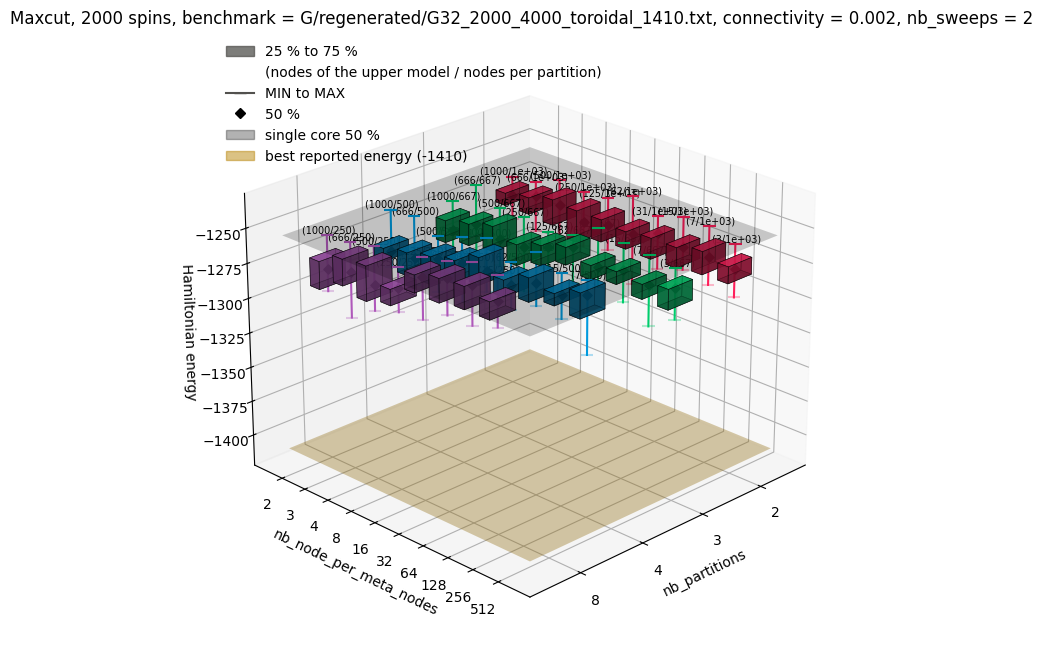

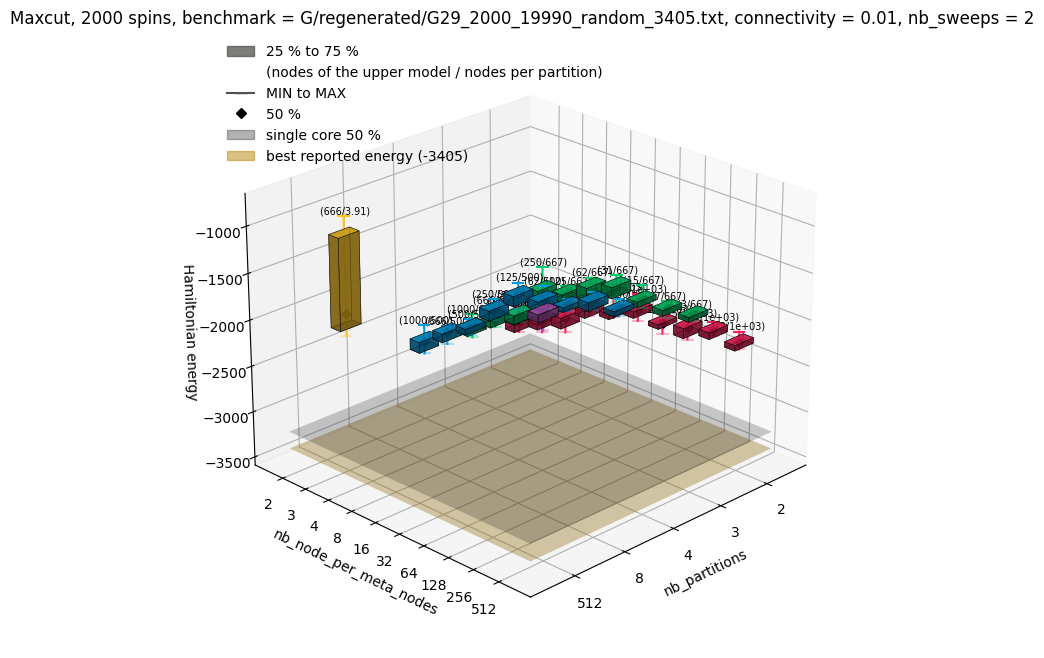

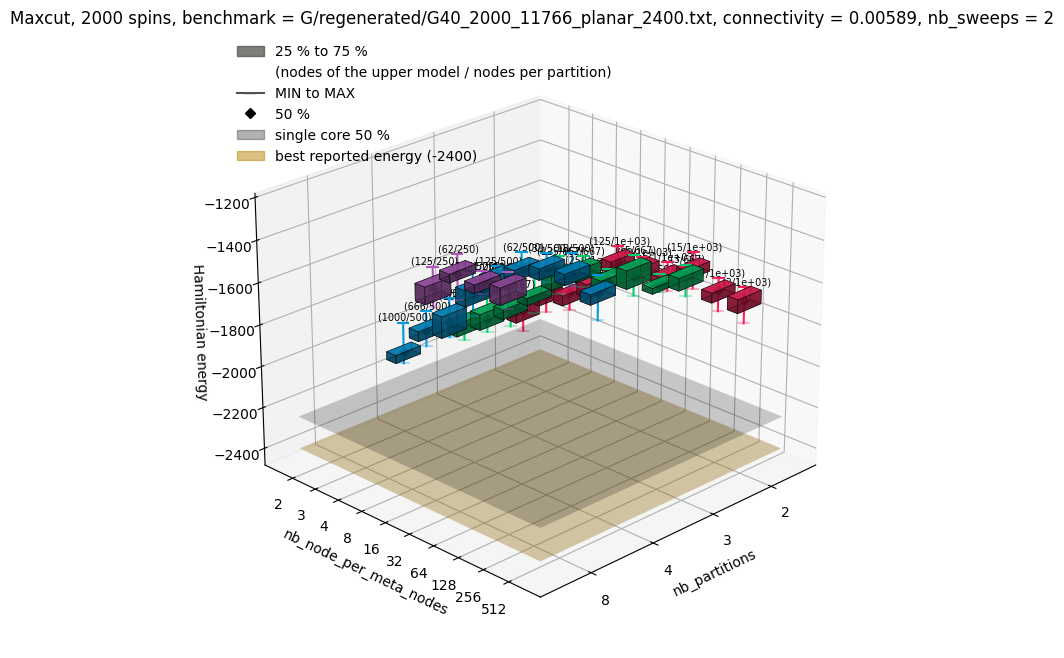

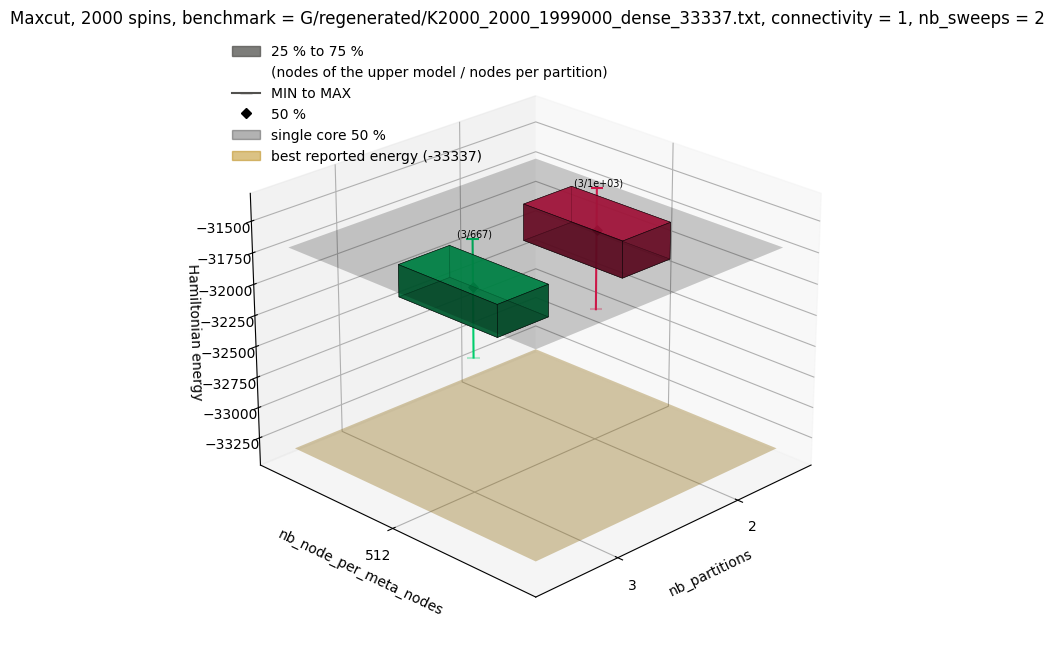

In [12]:
# MIN, 25 %, 50 %, 75 % and MAX of each point

for benchmark in saved["benchmark"].unique():
    utils.plot_energy_3d(saved, y="nb_node_per_meta_nodes", benchmark=benchmark, **fixed("benchmark", "nb_partitions", "nb_node_per_meta_nodes"))
#fig = utils.plot_energy_3d(saved, y="nb_node_per_meta_nodes", **fixed("nb_partitions", "nb_node_per_meta_nodes"))

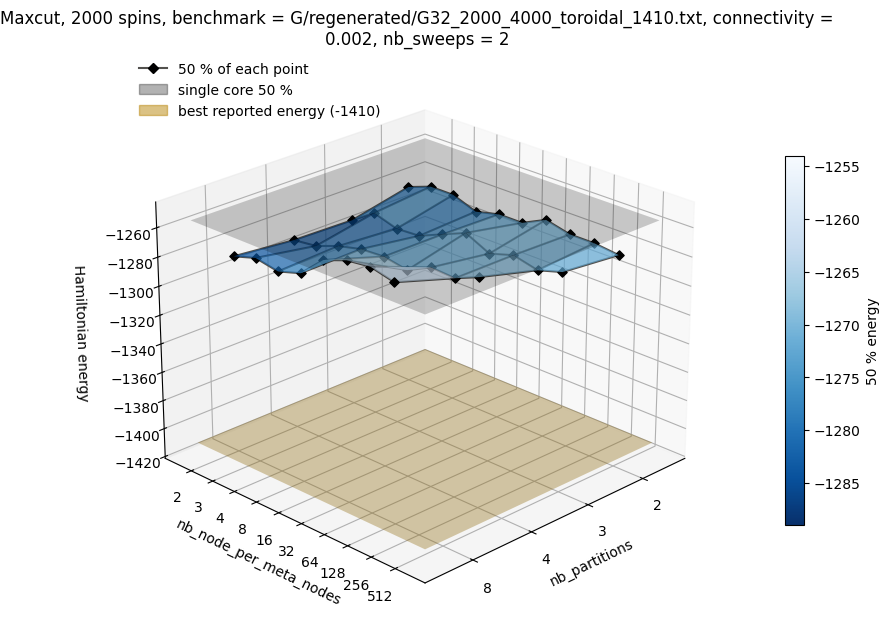

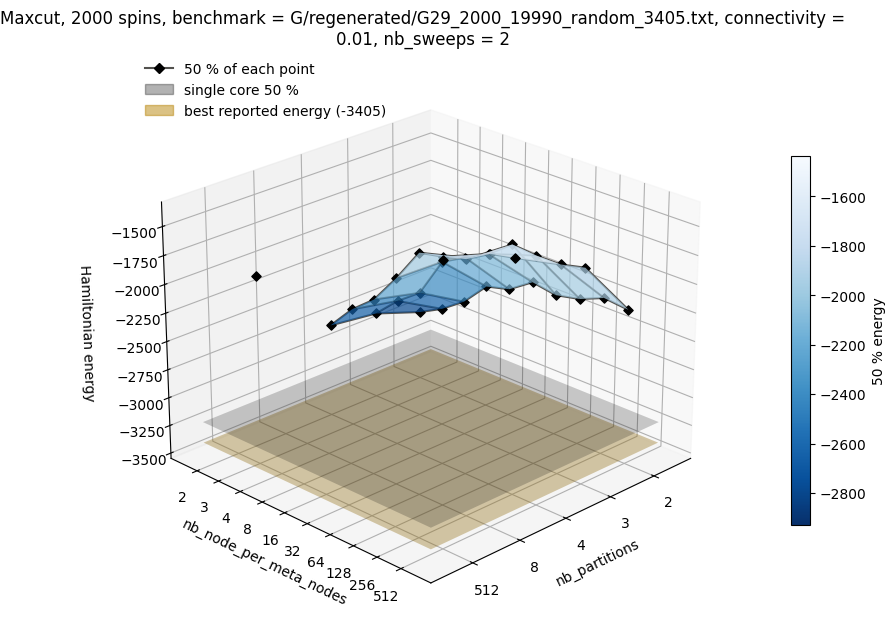

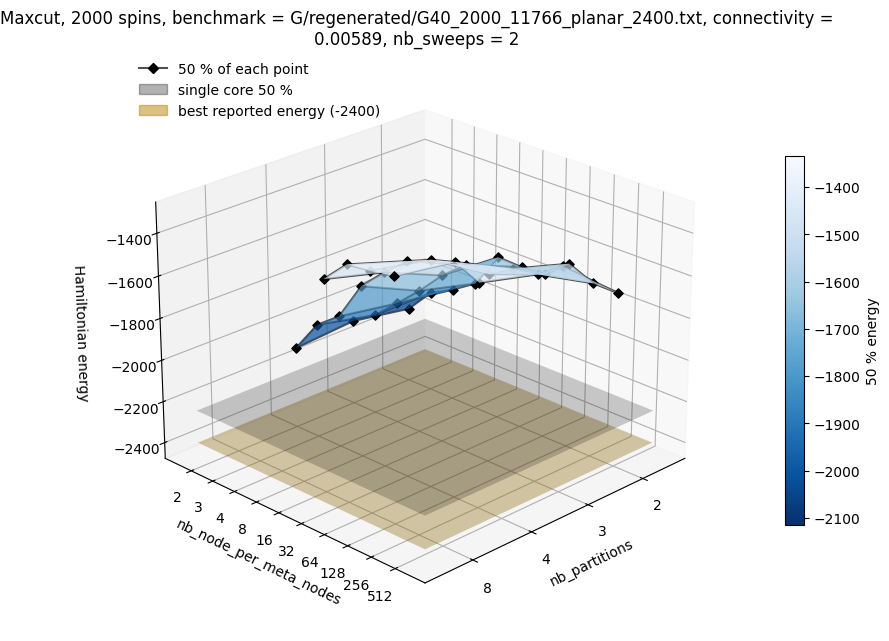

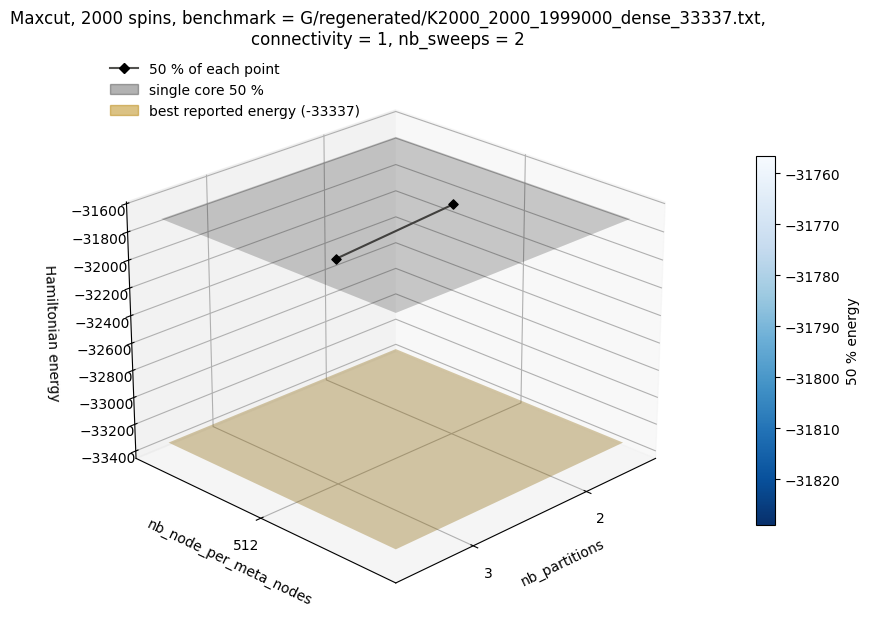

In [8]:
for benchmark in saved["benchmark"].unique():
    utils.plot_energy_3d_mean(saved, y="nb_node_per_meta_nodes", benchmark=benchmark, **fixed("benchmark", "nb_partitions", "nb_node_per_meta_nodes"))

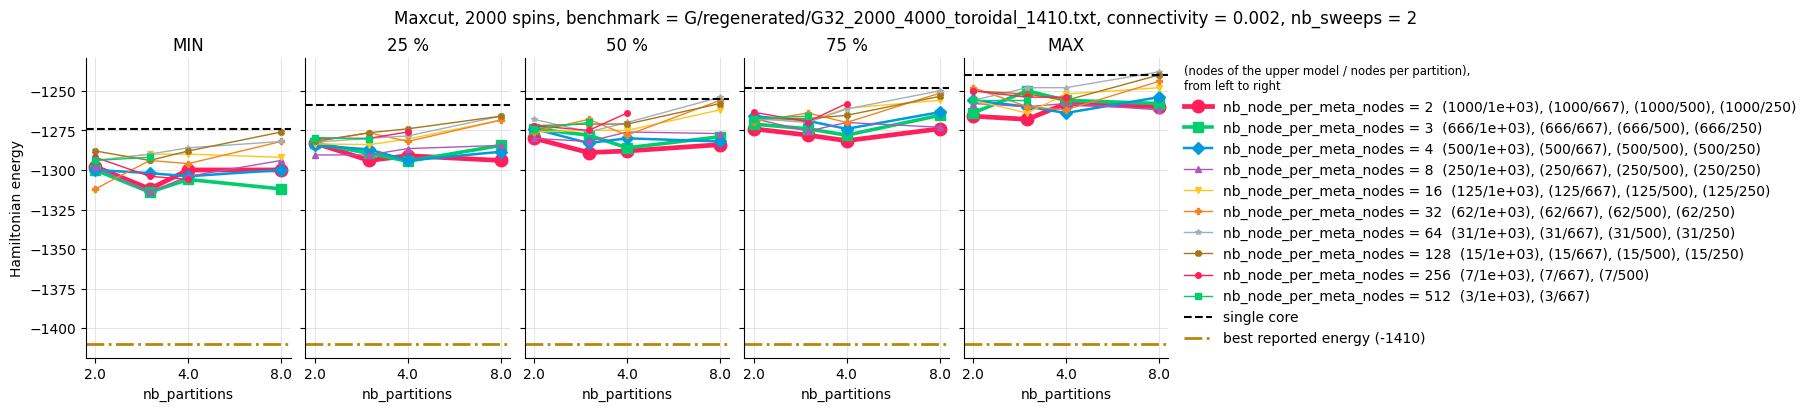

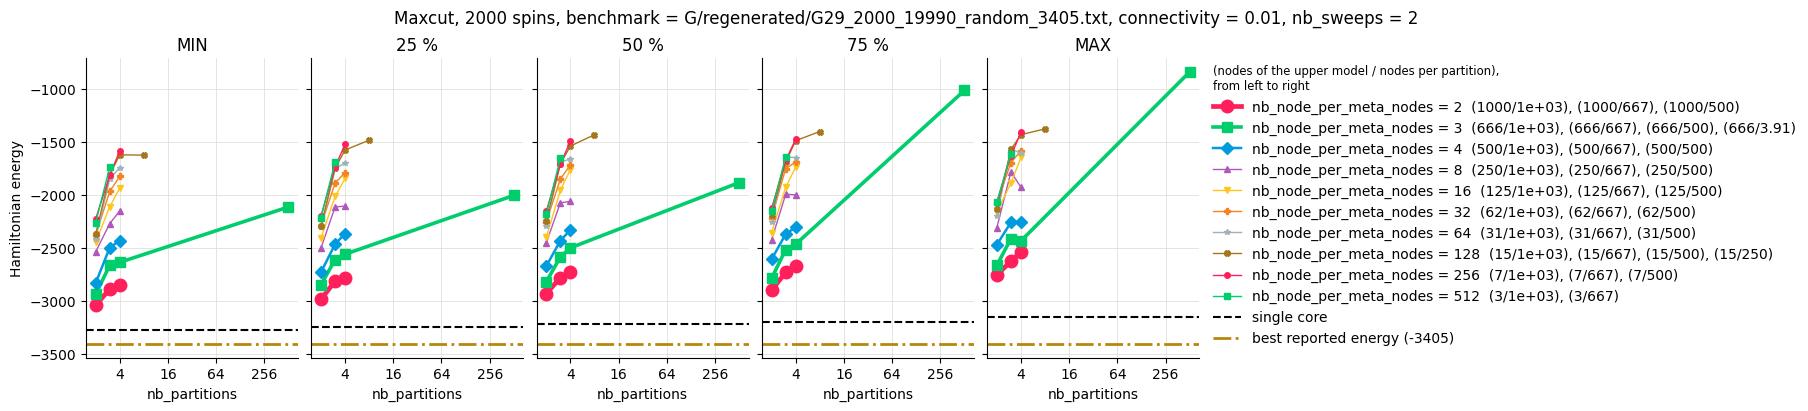

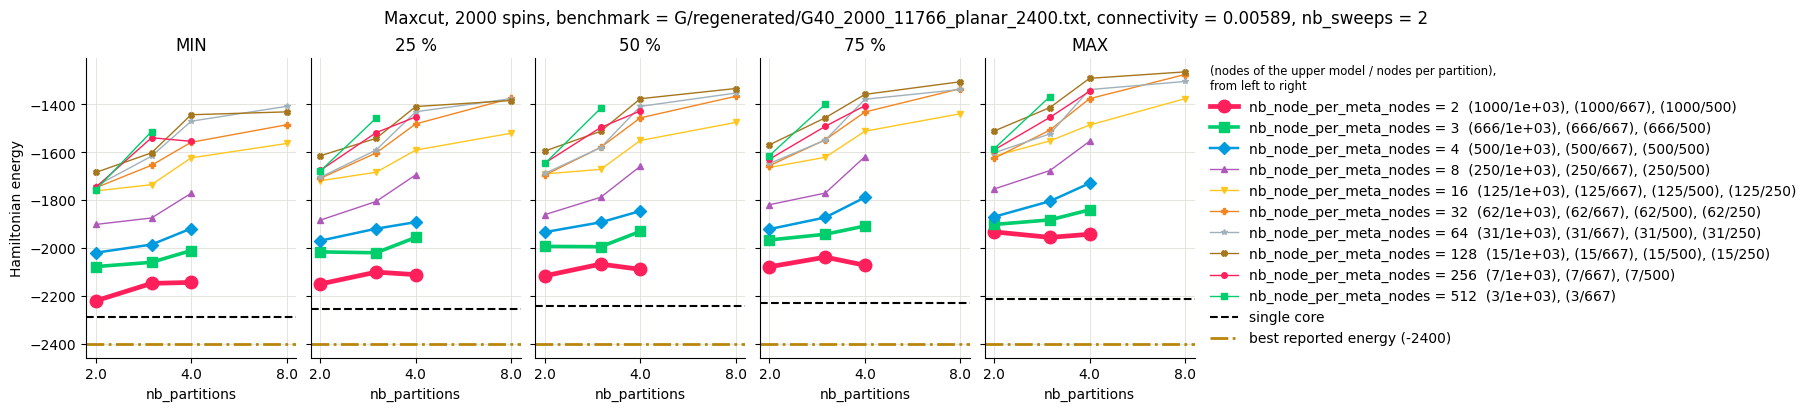

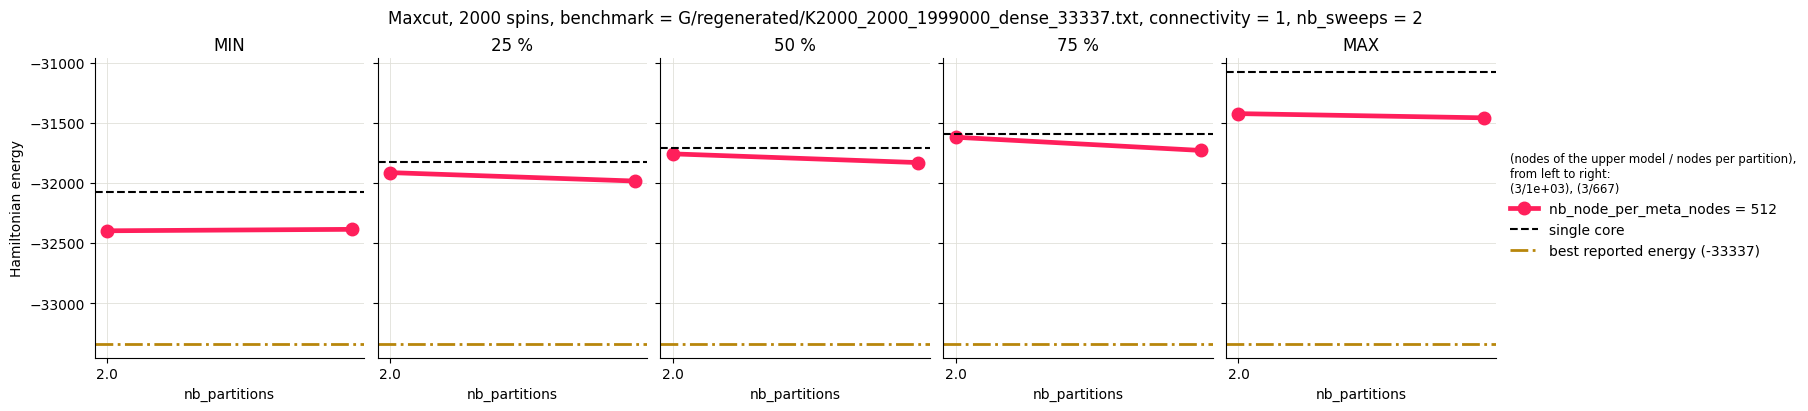

In [14]:
for benchmark in saved["benchmark"].unique():
    utils.plot_energy_lines(saved, x="nb_partitions", by="nb_node_per_meta_nodes", relative=False, logscale=2, benchmark=benchmark, **fixed("benchmark", "nb_partitions", "nb_node_per_meta_nodes"))

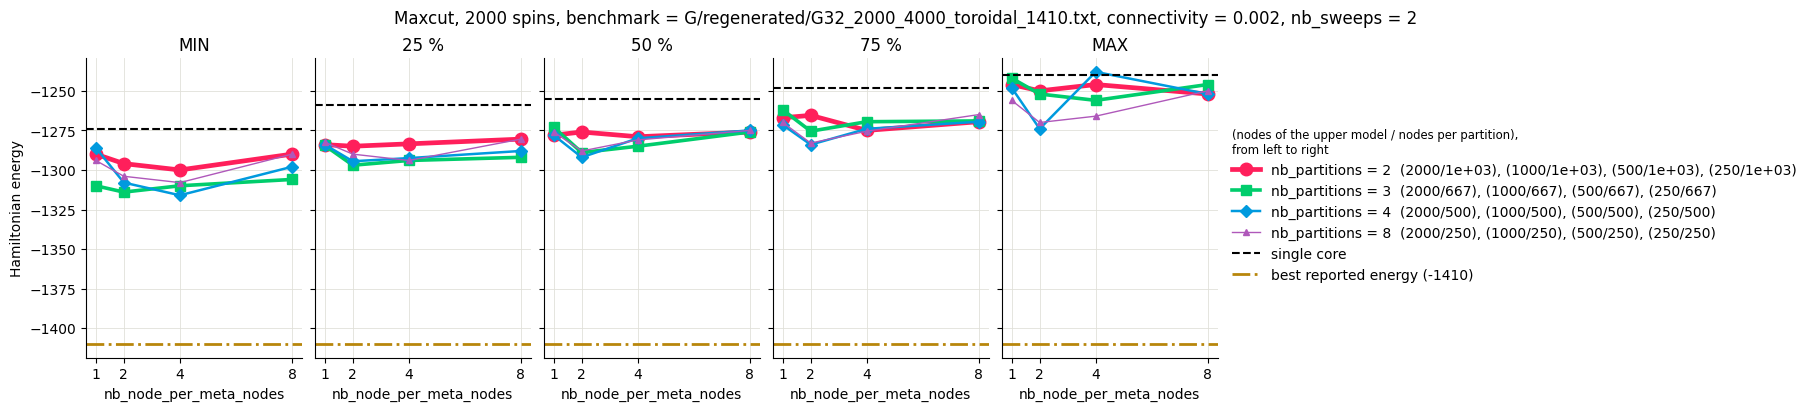

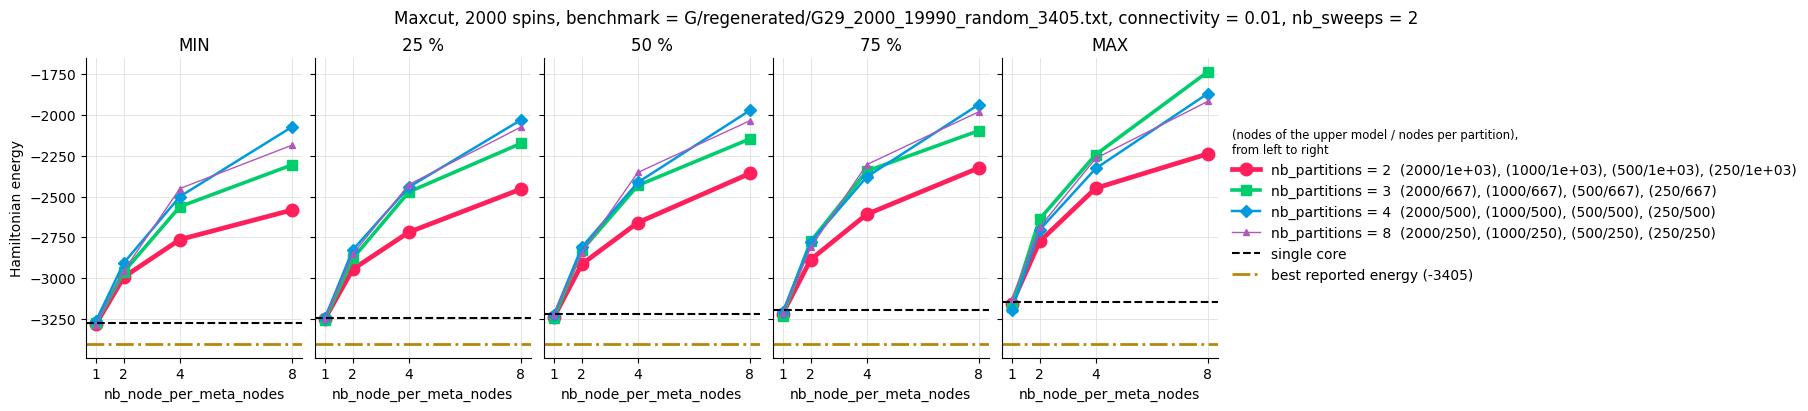

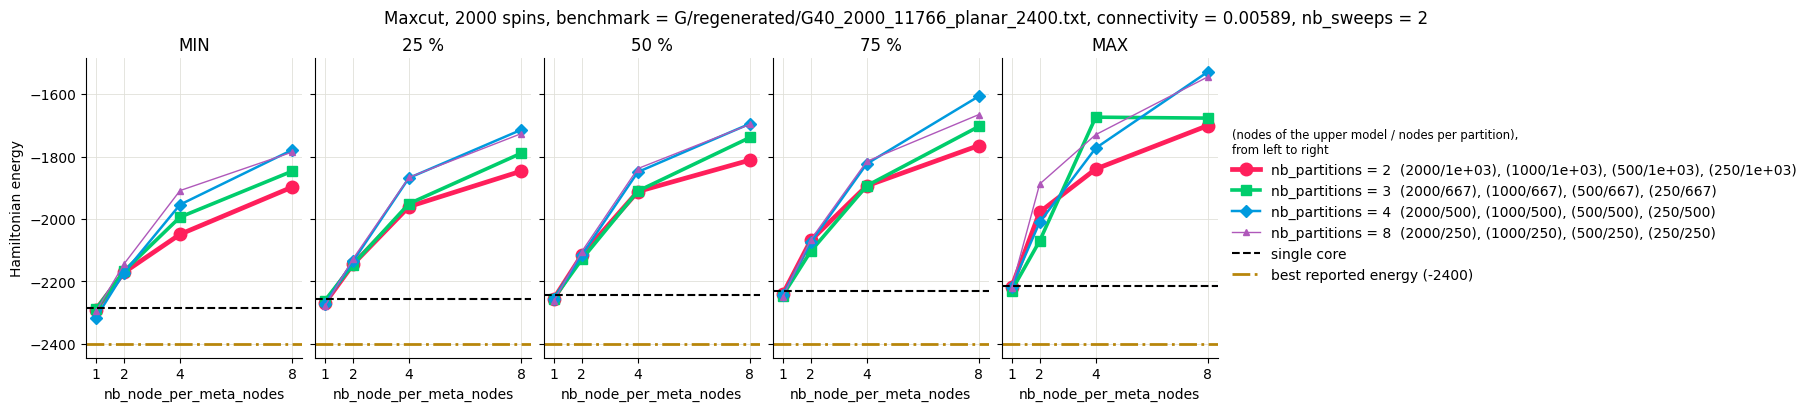

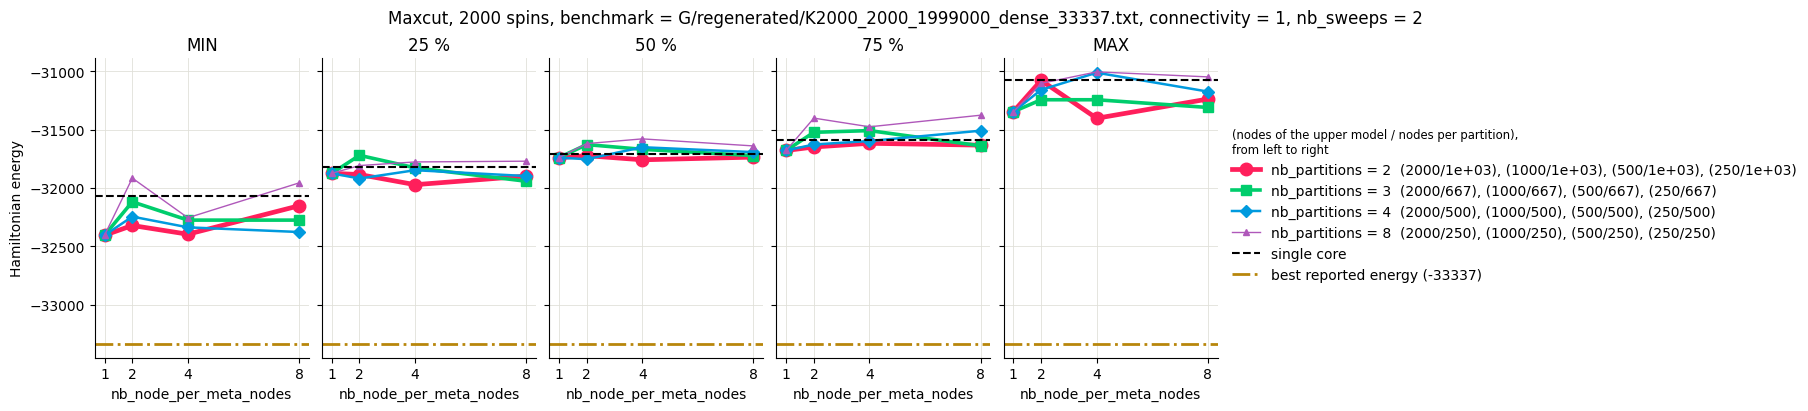

In [32]:
for benchmark in saved["benchmark"].unique():
    utils.plot_energy_lines(saved, x="nb_node_per_meta_nodes", by="nb_partitions", relative=False, benchmark=benchmark, **fixed("benchmark", "nb_partitions", "nb_node_per_meta_nodes"))

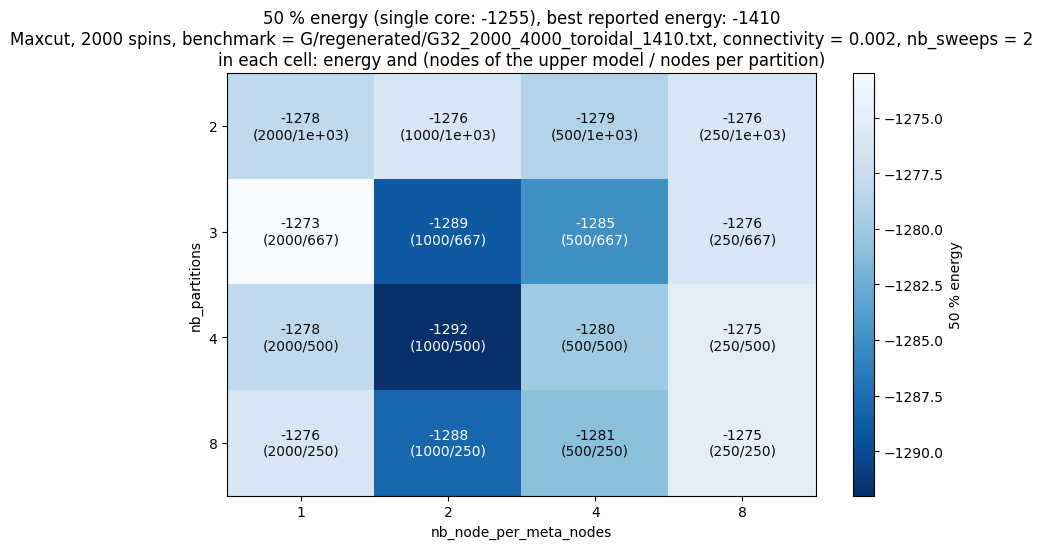

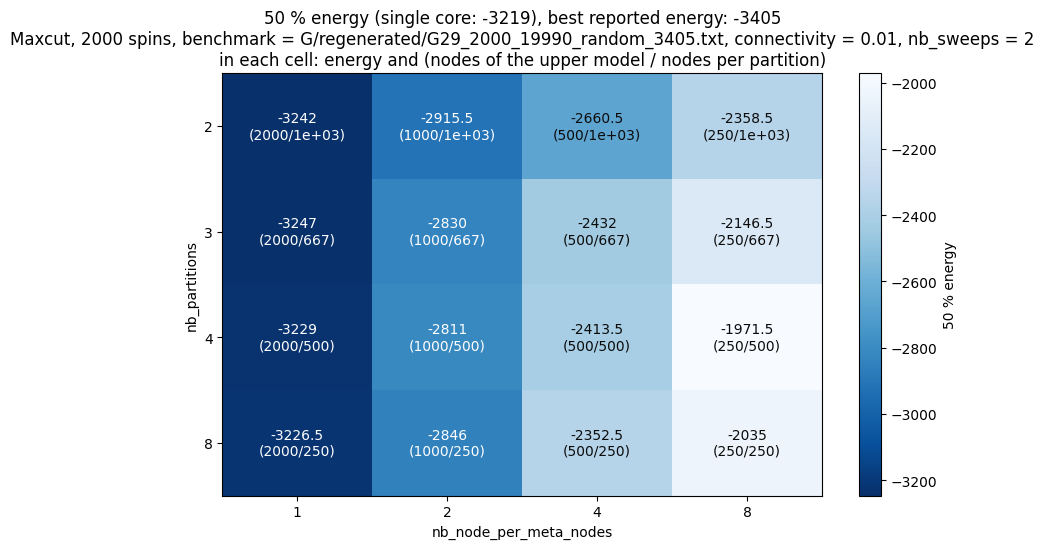

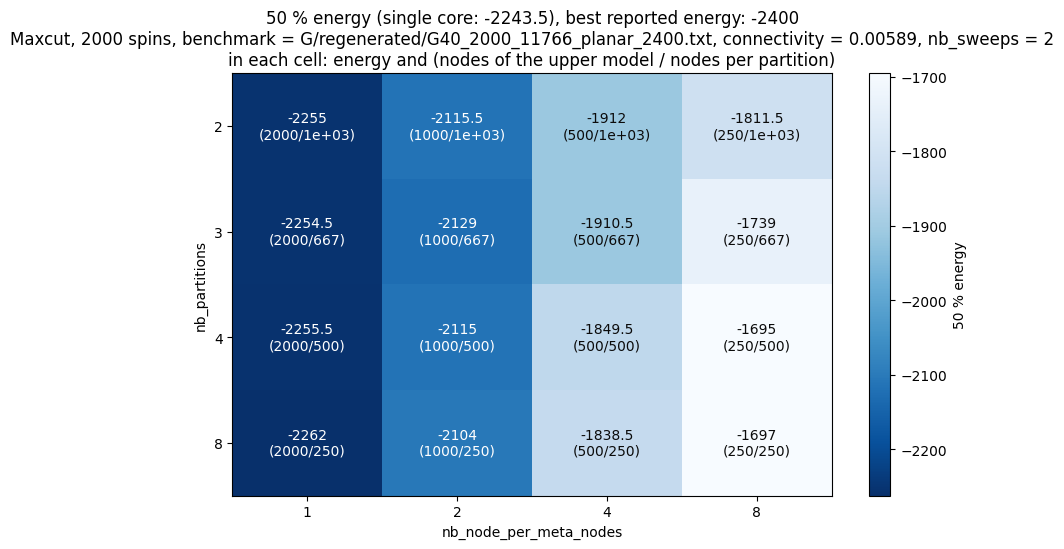

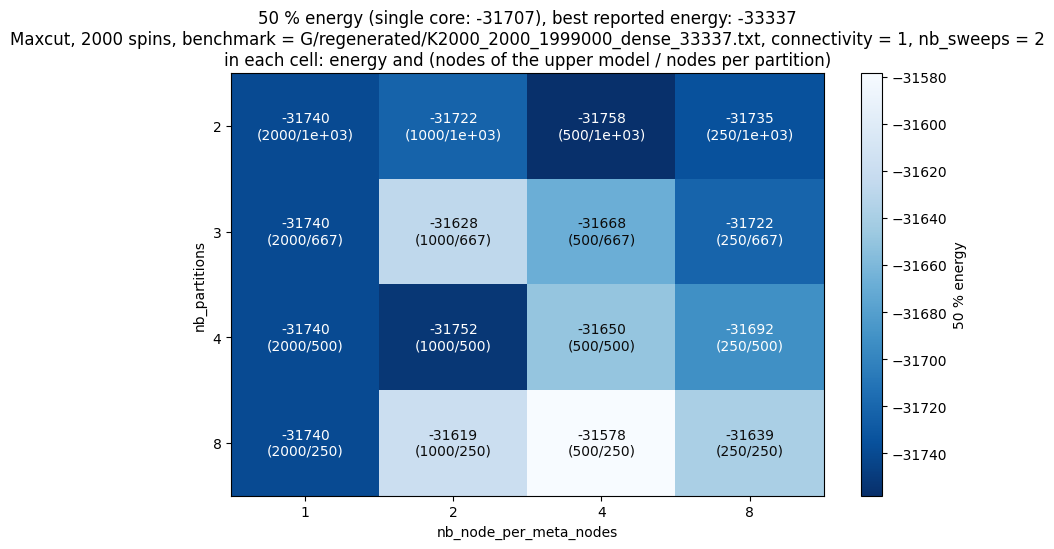

In [28]:
for benchmark in saved["benchmark"].unique():
    utils.plot_energy_heatmap(saved, stat="en_50", benchmark=benchmark, **fixed("benchmark", "nb_partitions", "nb_node_per_meta_nodes"))

### Model of the saved run

2026-10-06 21:20:04,465 - maxcut_parser_stage.py - get_optim_value +104 - WARNING - Optimal energy file /Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openising/ising/benchmarks/G/regenerated/optimal_energy.txt does not exist. Returning None.


/Users/ludovicblanc/Documents/Studies/EPFL/PHD/tclgit/ising/openising/ising/stages/maxcut_parser_stage.py:50: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  coupling = -nx.adjacency_matrix(graph, weight="weight").toarray() / 2


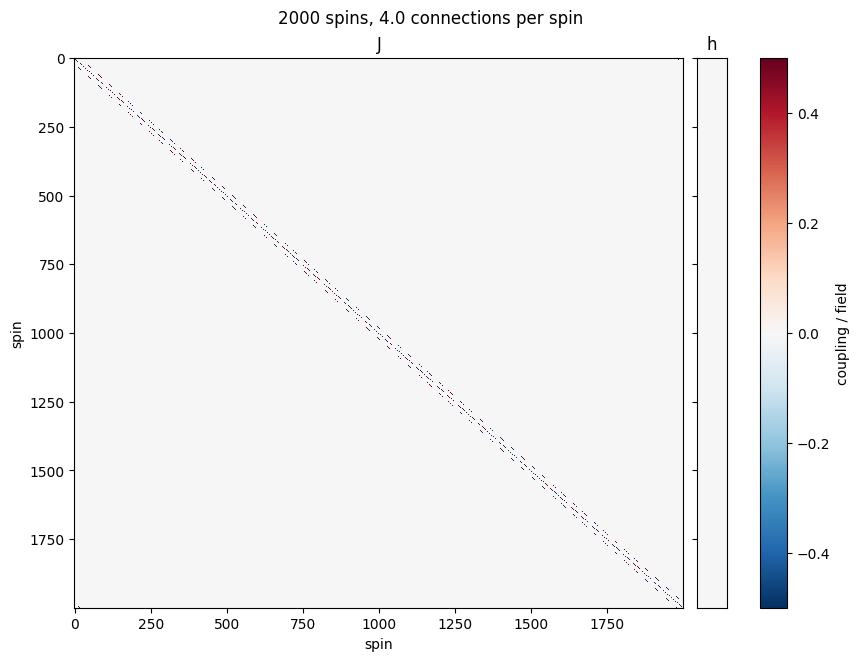

In [41]:
# J and h of the selected benchmark or connectivity: the yaml gives the same problem again
selected_config = dict(saved_config, nb_sweeps_Hierarchical_solver=int(SELECTED["nb_sweeps"]))
if "benchmark" in SELECTED:
    selected_config = utils.set_benchmark(selected_config, SELECTED["benchmark"])
else:
    selected_config["dummy_connectivity"] = SELECTED["connectivity"]
fig = utils.plot_model(runs.generate_problem(selected_config)["ising_model"])

In [ ]:
# utils.save_figure(fig, csv_path.stem + "_model")   # to figures/, as pdf

In [77]:
selected_config 

{'SNR': 10,
 'T': 50.0,
 'T_final': 0.05,
 'T_final_SCA': 0.5,
 'T_final_inSituSA': 0.5,
 'T_init_SCA': 50.0,
 'a0': 1.0,
 'accumulation_delay': 0.0,
 'benchmark': './ising/benchmarks/MIMO/user5_ant5_M16.txt',
 'broadcast_delay': 0.0,
 'c0': 0.0,
 'capacitance': 1,
 'cluster_choice': 'random',
 'cluster_threshold': 0.3,
 'combine_nodes': False,
 'core_solver': 'Multiplicative',
 'coupling_annealing': True,
 'current': 1.0,
 'delay_offset': 0.0,
 'device_noise': False,
 'do_flipping': True,
 'dtBRIM': '1e-6',
 'dtbSB': 0.01,
 'dtdSB': 0.01,
 'dummy_ant_num': 64,
 'dummy_bit_width': 16,
 'dummy_case_num': 10,
 'dummy_connectivity': 1.0,
 'dummy_creator': True,
 'dummy_density': 1,
 'dummy_penalty_value': 1.0,
 'dummy_precision': 4,
 'dummy_qam': 4,
 'dummy_seed': 42,
 'dummy_size': 1024,
 'dummy_snr': 8,
 'dummy_spacing': 1.0,
 'dummy_user_num': 16,
 'dummy_weight_constant': 0.0,
 'eigenvalue_start': False,
 'end_cluster_size': 0.1,
 'exponent': 3.0,
 'gen_logfile': False,
 'init_cluster